Isidora Popovic\
2024/3285\
Zadatak 4 Kafa

In the study of heat transfer, Newton's law of cooling is a physical law which states that the rate of heat loss of a body is directly proportional to the difference in the temperatures between the body and its environment.

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import math
from scipy import interpolate

dT/dt = k(T-T_sobe) -> \
T(t) = T_sobe + (T0 - T_sobe) * exp(-k t) -> \
ln (T(t) - T_sobe)=ln (T0 - T_sobe) -kt \
Da bismo rešili ovo, koristićemo linearnu regresiju\
Vidimo da se temperatura menja u zavisnosti od početne i sobne temperature, kao i konstante k

In [3]:
T_sobe = 22.3
t = np.arange(0, 1000, 30)
T = np.array([69.58, 66.11, 61.41, 58.07, 55.60, 53.58, 51.66, 50.05, 48.52, 47.24, 46.00, 44.96,
              43.96, 42.92, 41.95, 41.05, 40.18, 39.40, 38.70, 38.00, 37.32, 36.67, 36.08, 35.50,
              35.00, 34.53, 34.04, 33.59, 33.20, 32.76, 32.37, 32.00, 31.64, 31.30])
T0=T[0]

In [4]:
def newton_cooling(t, k, T0):
    return T_sobe + (T0 - T_sobe) * np.exp(-k * t)

In [5]:
y = np.log(T - T_sobe)
b, a = np.polyfit(t, y, 1)   
k_est = -b
T0_est = T_sobe + np.exp(a)  

In [6]:
def T_model(t_query):
    return T_sobe + (T0_est - T_sobe) * np.exp(-k_est * np.asarray(t_query, dtype=float))

t=1/k* ln(T_target-T_sobe/(T0-T_sobe))

In [7]:
def vreme_do_T(T_target):
    return -(1.0 / k_est) * np.log((T_target - T_sobe) / (T0_est - T_sobe))

In [8]:
vreme_do_T(26)

1505.8377999389957

In [9]:
def izracunaj_T_sobe(t, T_target, k, T0):
    alpha = math.exp(-k * t)
    return (T_target - alpha * T0) / (1.0 - alpha)

In [10]:
izracunaj_T_sobe(752,26,k_est,T0)

6.93010540687208

In [11]:
t_dense = np.linspace(t.min(), t.max(), 600)

In [12]:
#linear_interpolation
# \(y=y_{1}+((x-x_{1})/(x_{2}-x_{1}))*(y_{2}-y_{1})\)
lin = interpolate.interp1d(t, T, kind="linear")     
T_lin = lin(t_dense)

In [13]:
#cubic_interpolation

pchip = interpolate.PchipInterpolator(t, T)     
T_pchip = pchip(t_dense)

In [14]:
#ekspoencijalna
y = np.log(T - T_sobe)
slope, intercept = np.polyfit(t, y, 1)
k_est = -slope
T0_est = T_sobe + np.exp(intercept)


In [15]:
def T_newton(tt):
    tt = np.asarray(tt, dtype=float)
    return T_sobe + (T0_est - T_sobe) * np.exp(-k_est * tt)

T_fit_newton_dense = T_newton(t_dense)
T_fit_newton_pts   = T_newton(t)

In [16]:
#radial_base_function
rbf = interpolate.Rbf(t, T, function='quintic', smooth=0)
T_rbf = rbf(t_dense)

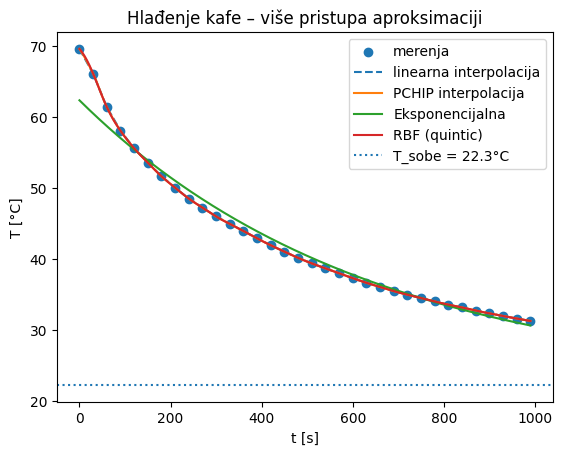

In [17]:
plt.figure()
plt.scatter(t, T, label="merenja")
plt.plot(t_dense, T_lin, linestyle="--", label="linearna interpolacija")
plt.plot(t_dense, T_pchip, label="PCHIP interpolacija")
plt.plot(t_dense, T_fit_newton_dense, label="Eksponencijalna")
plt.plot(t_dense, T_rbf, label="RBF (quintic)")
plt.axhline(T_sobe, linestyle=":", label=f"T_sobe = {T_sobe}°C")
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("Hlađenje kafe – više pristupa aproksimaciji")
plt.legend()

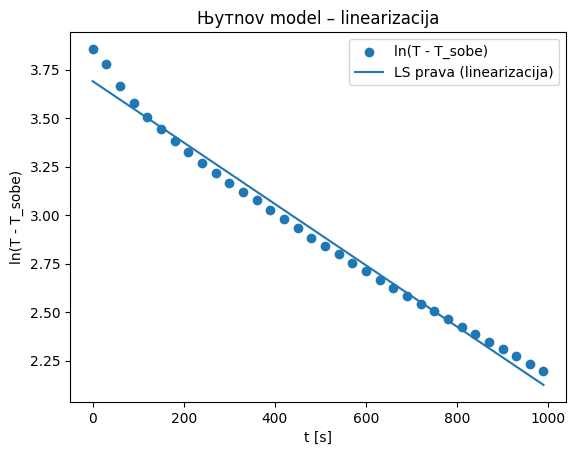

In [18]:
plt.figure()
plt.scatter(t, y, label="ln(T - T_sobe)", zorder=3)
plt.plot(t_dense, intercept + slope * t_dense, label="LS prava (linearizacija)")
plt.xlabel("t [s]")
plt.ylabel("ln(T - T_sobe)")
plt.title("Њутnov model – linearizacija")
plt.legend()

Za monotono hlađenje PCHIP je često „najsigurniji“ za očuvanje monotonosti; RBF je fleksibilniji ali može blago oscilovati između tačaka (posebno na krajevima\
Za linearnu aproksimaciju vidimo da je solidna ali da ne prati najbolje sam oblik raspodele, ali prolazi kroz sve zadate tacke. Funkcija je monotona.\
Za PCHIP intrpolaciju znamo da čuva oblik i monotonost, gladja i realističnija od linearne, bez overshoota.\

Odstupanja: tipično manja RMSE/MAE između tačaka;

Srednja kvadratna greška (MSE) osetljiva, ali daje dobro tumacenje

Srednja apsolutna greška (MAE) manje osetljiva

korelacija

glatkoća (izbor aproksimacije)

Srednja vrednost nam govori o odstupanjima naše aproksimacije u odnosu na fizički model. Korelaciju možemo posmatrati između modela i aproksimacija, a glatkoća nam zapravo govori o izboru aproksimacije, o čemu smo govorili malopre — da li ćemo uzeti linearnu, koja je izlomljena, ali nam brzo daje osećaj za odstupanje, ili eksponencijalnu, koja modeluje sam fizički proces, ili funkcije višeg reda, koje prate krivu i daju najmanja odstupanja, ali su računski zahtevne